# Appendix D — Sharpe, rolling Sharpe, and Sharpe Stability Ratio of the most-traded ETFs

Unlike appendices B and C this notebook reads the FMP `etf_prices` feed from the local DB (it needs the full 112-symbol cross-section to rank by traded volume).

Universe rule: the 15 ETFs with the highest **median daily dollar volume** (close × volume) over the full 2010–2026 feed. Median, not mean, so a single frantic week can't promote a fund. Dollar volume is the popularity proxy the price feed itself supports; AUM would work too but isn't in the FMP tables we store.

Three statistics per fund, on daily close-to-close returns with rf = 0 (the repo's Sharpe convention):

- **Sharpe** — full-sample `mean/std · √252`.
- **Rolling Sharpe** — the same on a trailing 252-day window (`macro_framework.ssr.rolling_sharpe`), the time series `Z_t` the stability measure works on.
- **SSR (Sharpe Stability Ratio)** — Bajo Traver & Rodríguez Domínguez (2026): `SSR = mean(Z) / σ_HAC(Z)`, where `σ_HAC` is the Newey-West long-run volatility of the rolling-Sharpe path (Bartlett kernel, Andrews bandwidth). It asks not "how high is the Sharpe" but "how much of the time was it actually there." A high-Sharpe fund that earns everything in two spikes scores low; a modest but steady earner scores high.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
from sqlalchemy import text

from macro_framework.db import get_engine
from macro_framework.ssr import compute_ssr, rolling_sharpe, ssr_inference

pd.set_option("display.width", 200)
TOP_N = 15
WINDOW = 252

with get_engine().connect() as conn:
    px = pd.read_sql(text("SELECT symbol, date, close, volume FROM etf_prices"),
                     conn, parse_dates=["date"])
    meta = pd.read_sql(text("SELECT symbol, name, category FROM etf_meta"),
                       conn).set_index("symbol")

px["dollar_vol"] = px["close"] * px["volume"]
mdv = px.groupby("symbol")["dollar_vol"].median().sort_values(ascending=False)
TOP = mdv.head(TOP_N).index.tolist()
print(f"top {TOP_N} of {mdv.size} symbols by median daily dollar volume:")
print(", ".join(TOP))

close = px.pivot(index="date", columns="symbol", values="close")[TOP]
rets = close.pct_change()
print(f"\nspan: {close.index.min():%Y-%m-%d} .. {close.index.max():%Y-%m-%d}  ({len(close)} rows)")

top 15 of 112 symbols by median daily dollar volume:
SPY, QQQ, IWM, EEM, XLF, TLT, GLD, EFA, HYG, XLE, IVV, DIA, FXI, GDX, EWZ

span: 2010-01-04 .. 2026-05-29  (4238 rows)


## 1. The table

One row per fund, sorted by SSR. `median $vol/day` is the selection criterion; `mean roll SR` and `σ_HAC` are the numerator and denominator of the SSR; `L` is the Newey-West lag the Andrews rule picked. `MBB p` is the one-sided moving-block-bootstrap p-value from the SSR paper's Test 1 (`macro_framework.ssr.ssr_inference`, the repo's verdict authority): SSR is the effect size, the bootstrap p is the verdict.

In [2]:
def fund_row(sym):
    r = rets[sym].dropna()
    inf = ssr_inference(r, window=WINDOW)   # SSR effect size + one-sided MBB p (Test 1)
    res = inf.result
    yrs = (r.index[-1] - r.index[0]).days / 365.25
    cagr = float((1 + r).prod() ** (1 / yrs) - 1)
    return {
        "name": meta.loc[sym, "name"],
        "median $vol/day (M)": mdv[sym] / 1e6,
        "CAGR": cagr,
        "ann. vol": float(r.std(ddof=1) * np.sqrt(252)),
        "Sharpe": res.sr_full,
        "mean roll SR": res.mean_rolling_sr,
        "sigma_HAC": res.sigma_hac,
        "L": res.L_hac,
        "SSR": res.ssr,
        "MBB p": inf.p_value,
        "verdict": "stably > 0" if inf.stable else "luck-compatible",
    }


table = pd.DataFrame({s: fund_row(s) for s in TOP}).T.sort_values("SSR", ascending=False)
for c in ["median $vol/day (M)", "CAGR", "ann. vol", "Sharpe", "mean roll SR", "sigma_HAC", "SSR", "MBB p"]:
    table[c] = table[c].astype(float)

fmt = table.copy()
fmt["median $vol/day (M)"] = fmt["median $vol/day (M)"].map("{:,.0f}".format)
fmt["CAGR"] = fmt["CAGR"].map("{:.1%}".format)
fmt["ann. vol"] = fmt["ann. vol"].map("{:.1%}".format)
for c in ["Sharpe", "mean roll SR", "sigma_HAC", "SSR"]:
    fmt[c] = fmt[c].map("{:.2f}".format)
fmt["MBB p"] = fmt["MBB p"].map("{:.3f}".format)
display(fmt)

reports = Path.cwd().parent / "reports"
reports.mkdir(exist_ok=True)
table.to_csv(reports / "appendix_d_popular_etf_ssr.csv", float_format="%.6f")
print(f"wrote {reports / 'appendix_d_popular_etf_ssr.csv'}")

,name,median $vol/day (M),CAGR,ann. vol,Sharpe,mean roll SR,sigma_HAC,L,SSR,MBB p,verdict
QQQ,Invesco QQQ Trust,"5,401",17.7%,20.7%,0.92,1.05,8.72,182,0.12,0.000,stably > 0
SPY,SPDR S&P 500 ETF Trust,"24,172",12.5%,17.2%,0.79,1.00,8.83,182,0.11,0.000,stably > 0
IVV,iShares Core S&P 500 ETF,"1,048",12.6%,17.3%,0.79,1.00,8.88,182,0.11,0.000,stably > 0
DIA,SPDR Dow Jones Industrial Average ETF,983,10.7%,16.5%,0.72,0.96,9.15,182,0.10,0.000,stably > 0
IWM,iShares Russell 2000 ETF,"4,318",11.0%,22.3%,0.59,0.66,7.87,182,0.08,0.006,stably > 0
XLF,Financial Select Sector SPDR Fund,"1,327",10.4%,21.9%,0.57,0.82,10.03,182,0.08,0.009,stably > 0
EFA,iShares MSCI EAFE ETF,"1,225",4.2%,18.5%,0.32,0.45,8.78,182,0.05,0.103,luck-compatible
GLD,SPDR Gold Shares,"1,256",8.1%,16.5%,0.57,0.55,11.11,182,0.05,0.014,stably > 0
XLE,Energy Select Sector SPDR Fund,"1,154",6.4%,27.3%,0.37,0.42,8.96,182,0.05,0.056,luck-compatible
EEM,iShares MSCI Emerging Markets ETF,"2,051",4.1%,21.4%,0.30,0.35,9.28,182,0.04,0.082,luck-compatible


wrote /home/mc/projects/Global_Macro_AI_Factors/reports/appendix_d_popular_etf_ssr.csv


## 2. Rolling Sharpe through time

Trailing 252-day Sharpe per fund, resampled to month-ends for legibility, rows in table order (best SSR at the top). Diverging scale, white at zero: blue = the trailing year earned its risk, red = it destroyed value. What SSR summarizes in one number is visible as texture here — a stable fund is a long, mostly-blue stripe; an unstable one alternates.

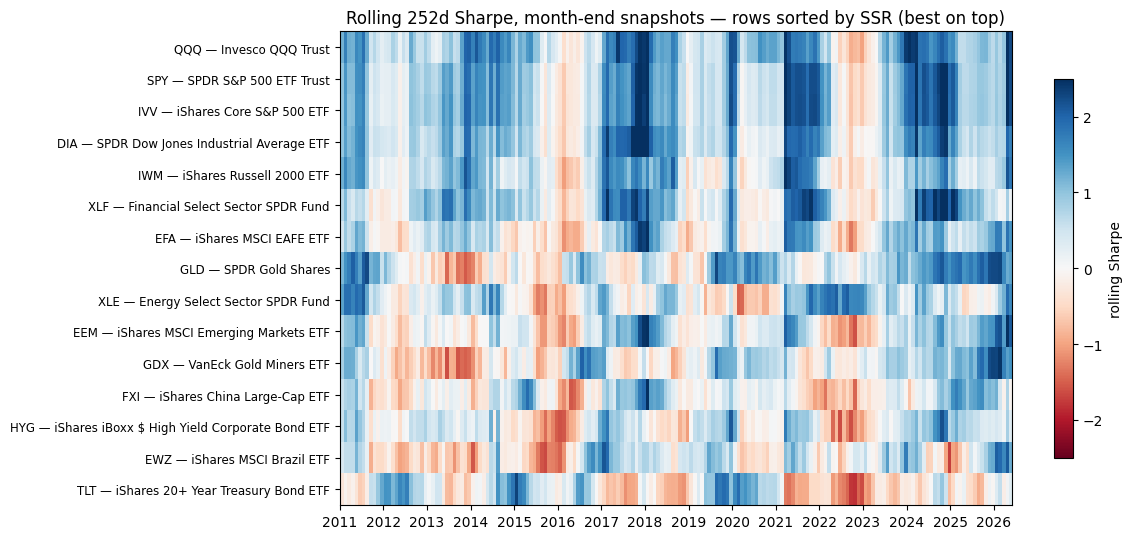

In [3]:
import matplotlib.pyplot as plt

roll = pd.DataFrame({s: rolling_sharpe(rets[s].dropna(), window=WINDOW) for s in TOP})
roll_m = roll.resample("ME").last()[table.index]  # table order: best SSR on top

fig, ax = plt.subplots(figsize=(12, 5.5))
im = ax.imshow(roll_m.T, aspect="auto", cmap="RdBu", vmin=-2.5, vmax=2.5,
               extent=[0, len(roll_m), len(TOP) - 0.5, -0.5])
xt = np.arange(0, len(roll_m), 12)
ax.set_xticks(xt)
ax.set_xticklabels([f"{d:%Y}" for d in roll_m.index[xt]])
ax.set_yticks(range(len(TOP)))
ax.set_yticklabels([f"{s} — {meta.loc[s, 'name']}" for s in table.index], fontsize=8.5)
ax.set_title(f"Rolling {WINDOW}d Sharpe, month-end snapshots — rows sorted by SSR (best on top)")
fig.colorbar(im, ax=ax, label="rolling Sharpe", shrink=0.8)
fig.tight_layout()
fig.savefig(Path.cwd().parent / "data" / "appendix_d_rolling_sharpe_heatmap.png",
            dpi=150, bbox_inches="tight")

## 3. Level vs stability

Left: the SSR ranking itself. Right: full-sample Sharpe against SSR — the two are correlated (they share a numerator) but the deviations are the point. Funds under the trend earned their Sharpe in bursts; funds above it earned less but kept it.

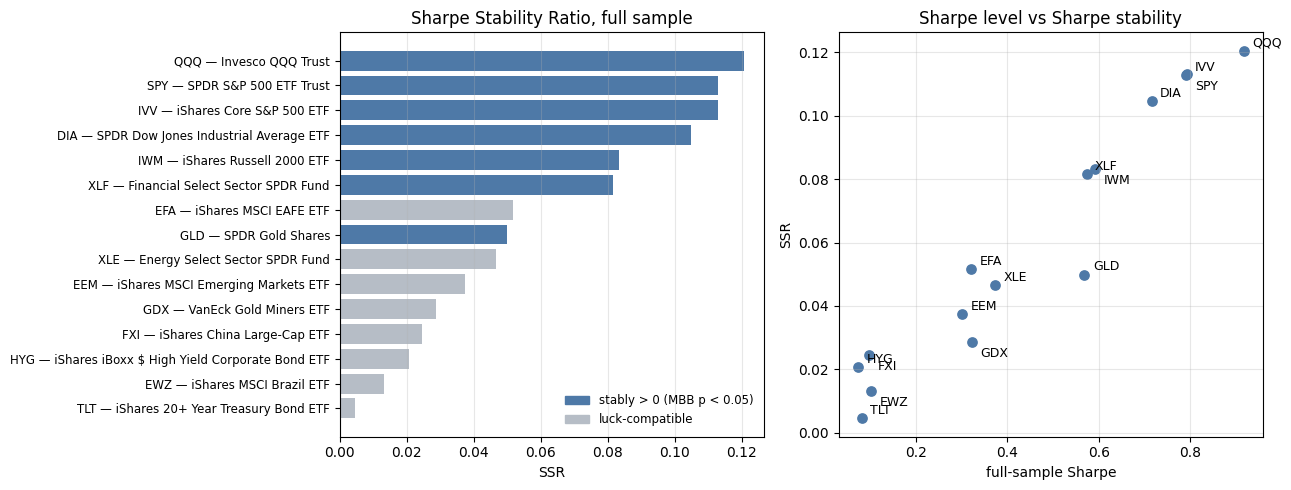

In [4]:
BLUE = "#4e79a7"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

t = table.iloc[::-1]  # barh plots bottom-up
GRAY = "#b6bdc6"
bar_colors = [BLUE if v == "stably > 0" else GRAY for v in t["verdict"]]
ax1.barh([f"{s} — {meta.loc[s, 'name']}" for s in t.index], t["SSR"], color=bar_colors)
ax1.tick_params(axis="y", labelsize=8.5)
from matplotlib.patches import Patch
ax1.legend(handles=[Patch(color=BLUE, label="stably > 0 (MBB p < 0.05)"),
                    Patch(color=GRAY, label="luck-compatible")],
           frameon=False, fontsize=8.5, loc="lower right")
ax1.set_xlabel("SSR")
ax1.set_title("Sharpe Stability Ratio, full sample")
ax1.grid(True, axis="x", alpha=0.3)

ax2.scatter(table["Sharpe"], table["SSR"], color=BLUE, s=45)
# alternate the label offset when two points nearly coincide (SPY/IVV, IWM/XLF)
placed = []
for sym, row in table.sort_values("Sharpe").iterrows():
    x, y = row["Sharpe"], row["SSR"]
    clash = any(abs(x - px) < 0.04 and abs(y - py) < 0.012 for px, py in placed)
    ax2.annotate(sym, (x, y), textcoords="offset points",
                 xytext=(6, -11) if clash else (6, 3), fontsize=9)
    placed.append((x, y))
ax2.set_xlabel("full-sample Sharpe")
ax2.set_ylabel("SSR")
ax2.set_title("Sharpe level vs Sharpe stability")
ax2.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(Path.cwd().parent / "data" / "appendix_d_ssr_ranking.png",
            dpi=150, bbox_inches="tight")

## 4. Reading the results

The stability ranking is mostly an index story. The four US large-cap trackers (QQQ, SPY, IVV, DIA) take the top four slots, and QQQ leads on both level (Sharpe 0.92) and stability (SSR 0.12). SPY and IVV are the built-in control: same index, 24× apart in traded dollars, metrics identical to the second decimal — SSR measures the return stream, not the wrapper.

The verdict column splits the table cleanly in two. The broad-equity trackers and the two sector/asset funds with steady premia pass the bootstrap test (MBB p < 0.05): their trailing-year Sharpe ran persistently above zero across fifteen years. The bottom of the table — developed-international (EFA, p=0.10), energy (XLE, p=0.056, just over the line), emerging markets, China, Brazil, gold miners, high yield, long Treasuries — is formally luck-compatible: each had blue stretches on the heatmap, but nothing the bootstrap can distinguish from a lucky draw over the full span. This is the discrimination the verdict rule is for; under the repo's pre-2026-07 rule (SSR ≥ 1.96) every fund here, QQQ included, was branded luck-compatible, which said more about the rule than the funds (see `docs/ssr_verdict_review.md`).

GLD against XLF is the level-vs-stability distinction in one pair: identical full-sample Sharpe (0.57), but SSR 0.05 versus 0.08 — both pass, gold with less room. TLT sits last at SSR 0.00: whatever the 2010s duration bull built, 2022 took back, leaving a full-sample mean near zero — there is little for stability to measure.

Two technical notes. First, σ_HAC is large (≈ 9–10) and the Andrews rule picks L = 182 for every fund: overlapping 252-day windows make the rolling-Sharpe path extremely persistent, so its long-run variance is big and all SSRs land in a narrow 0.00–0.12 band — SSR is an effect size for ranking; the MBB p carries the significance verdict. The strategy lines elsewhere in the repo (nb05, nb15.2) sit in the same 0.11–0.15 band and likewise pass. Second, FMP closes are price-only, not total return: income-heavy funds lose their coupon stream in these numbers. HYG's near-zero CAGR is its price series doing exactly what a bond fund's price should; its total-return Sharpe, SSR, and verdict would likely improve. More broadly, price-only data can shift **all** relative rankings at the margin, not just bond funds, so read the table as a price-behavior ranking rather than an exact total-return league table.